# Hands-on Lab 1 (Session 2): Transfer Learning Basico para Vision por Computador

**Nivel:** Introductorio / Fundacional  
**Framework:** Keras 3 (Multi-Backend: JAX, PyTorch o TensorFlow)  
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jggomez/workshop-open-models/blob/main/session-02-transfer-learning/01-transfer-learning-vision-basics/01_transfer_learning_vision_basics.ipynb)

---

## 1. Introduccion Teorica al Transfer Learning

El **Transfer Learning** (Aprendizaje por Transferencia) es una de las tecnicas mas eficientes del Deep Learning moderno. En lugar de entrenar una red neuronal desde cero (lo que requiere millones de imagenes etiquetadas y semanas de computo en clusters de GPUs), aprovechamos el conocimiento visual general adquirido por un modelo pre-entrenado sobre un dataset masivo como **ImageNet-1k** (1.4 millones de imagenes y 1,000 clases).

### La Estrategia de Extraccion de Caracteristicas (Feature Extraction)
Una red convolucional pre-entrenada se organiza jerarquicamente:
1. **Capas Iniciales:** Detectan patrones visuales de bajo nivel (bordes, gradientes, texturas basicas, esquinas).
2. **Capas Intermedias:** Combinan texturas para formar patrones complejos (formas geometricas, rejillas, partes de objetos).
3. **Capas Finales (Backbone Superior):** Representan conceptos semanticos de alto nivel (ojos, ruedas, hojas, petalos).
4. **Cabezal de Clasificacion (Classification Head):** Mapea esas representaciones semanticas a las clases objetivo del dataset original.

En la tecnica de **Feature Extraction**, congelamos el backbone (`trainable = False`) para conservar intactos todos los pesos pre-entrenados y reemplazamos unicamente el cabezal final por una nueva capa adaptada a nuestras clases objetivo.

### Objetivos Pedagogicos de este Laboratorio
- Descargar y estructurar un dataset de clasificacion de imagenes con Keras.
- Implementar un pipeline de aumentacion de datos nativo (`RandomFlip`, `RandomRotation`).
- Instanciar el backbone **MobileNetV2** pre-entrenado en ImageNet sin el cabezal original (`include_top=False`).
- Congelar los pesos del backbone para evitar su modificacion durante el entrenamiento inicial.
- Acoplar un cabezal personalizado con `GlobalAveragePooling2D`, `Dropout` y `Dense` con activacion Softmax.
- Entrenar el modelo, monitorear la convergencia y graficar las curvas de aprendizaje.
- Evaluar el modelo con inferencias sobre imagenes de prueba.


### Paso 1: Instalacion de Dependencias y Configuracion del Entorno

Instalamos Keras 3 y las bibliotecas auxiliares de computo y visualizacion:


In [1]:
!pip install -q --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.1 MB/s eta 0:00:00


### Paso 2: Seleccion de Backend e Importacion de Modulos

Keras 3 permite elegir el backend numerico subyacente mediante la variable de entorno `KERAS_BACKEND`. Para este ejercicio utilizamos TensorFlow o PyTorch de forma transparente:


In [2]:
import os

# Seleccionar backend si no esta preconfigurado
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "tensorflow"  # o "torch" o "jax"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pathlib

print(f"Keras version: {keras.__version__}")
print(f"Backend activo: {keras.backend.backend()}")

Keras version: 3.15.1
Backend activo: tensorflow


### Paso 3: Descarga y Preparacion del Dataset (Flower Photos)

Utilizamos el dataset estandar `flower_photos` (aproximadamente 3,670 fotografias distribuidas en 5 clases: margaritas, dientes de leon, rosas, girasoles y tulipanes):


In [11]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

# Correcting the data_dir to point to the actual folder containing class subdirectories
data_dir = data_dir / 'flower_photos'

image_count = len(list(data_dir.glob("*/*.jpg")))
print(f"Total de imagenes encontradas: {image_count}")

# Clases detectadas
class_names = sorted([item.name for item in data_dir.glob("*") if item.is_dir()])
print(f"Clases del dataset ({len(class_names)}): {class_names}")

Total de imagenes encontradas: 3670
Clases del dataset (5): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Paso 4: Creacion de Datasets de Entrenamiento y Validacion

Configuramos un split del 80% para entrenamiento y 20% para validacion, fijando una resolucion estandar de 224x224 pixeles (dimension nativa de MobileNetV2) con un tamano de lote (*batch size*) de 32:


In [16]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Optimizacion de lectura en buffer
AUTOTUNE = getattr(keras, "ops", None)
train_ds = train_ds.prefetch(buffer_size=2)
val_ds = val_ds.prefetch(buffer_size=2)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


### Paso 5: Pipeline de Aumentacion de Datos

La aumentacion de datos expone al modelo a variaciones espaciales artificiales durante el entrenamiento, reduciendo el riesgo de sobreajuste (*overfitting*) en datasets pequenos:


In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

### Paso 6: Construccion del Modelo con Backbone Pre-entrenado Congelado

Instanciamos **MobileNetV2** pre-entrenado en ImageNet:
- `include_top=False`: Excluye la capa densa original de 1,000 clases.
- `base_model.trainable = False`: **Paso clave de Transfer Learning**. Congela todos los pesos convolucionales, asegurando que no se actualicen durante el calculo del gradiente.
- `GlobalAveragePooling2D()`: Convierte los mapas de caracteristicas espaciales de 7x7x1280 en un vector compacto de 1280 dimensiones por imagen.
- `Dropout(0.2)`: Regularizacion probabilistica.
- `Dense(len(class_names), activation="softmax")`: Proyeccion lineal a las 5 clases de flores.


In [14]:
from keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

# 1. Instanciar backbone pre-entrenado
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# 2. Congelar el backbone
base_model.trainable = False

# 3. Ensamblar la arquitectura completa usando la API Funcional de Keras
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)  # Normalizacion a escala [-1.0, 1.0]
x = base_model(x, training=False)  # Mantener BatchNorm en modo inferencia
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs, name="transfer_learning_flowers")
model.summary()

Model: "transfer_learning_flowers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Paso 7: Compilacion y Entrenamiento del Modelo

Compilamos con el optimizador **Adam** y funcion de perdida `sparse_categorical_crossentropy`. Entrenamos durante 3 epocas para verificar la convergencia inicial del nuevo cabezal:


In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.6740 - loss: 0.8687 - val_accuracy: 0.8229 - val_loss: 0.4836
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8396 - loss: 0.4536 - val_accuracy: 0.8638 - val_loss: 0.3921
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8563 - loss: 0.3989 - val_accuracy: 0.8638 - val_loss: 0.4151
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8791 - loss: 0.3408 - val_accuracy: 0.8747 - val_loss: 0.3743
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8910 - loss: 0.3137 - val_accuracy: 0.8747 - val_loss: 0.3763
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9005 - loss: 0.2914 - val_accuracy: 0.8774 - val_loss: 0.3679
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9022 - loss: 0.2715 - val_accuracy: 0.8801 - val_loss: 0.3341
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9084 - loss: 0.2616 - val_accuracy: 0.8815 - val_loss: 0

### Paso 8: Visualizacion de las Curvas de Aprendizaje

Graficamos la evolucion de la precision (*accuracy*) y de la perdida (*loss*) en los subconjuntos de entrenamiento y validacion:


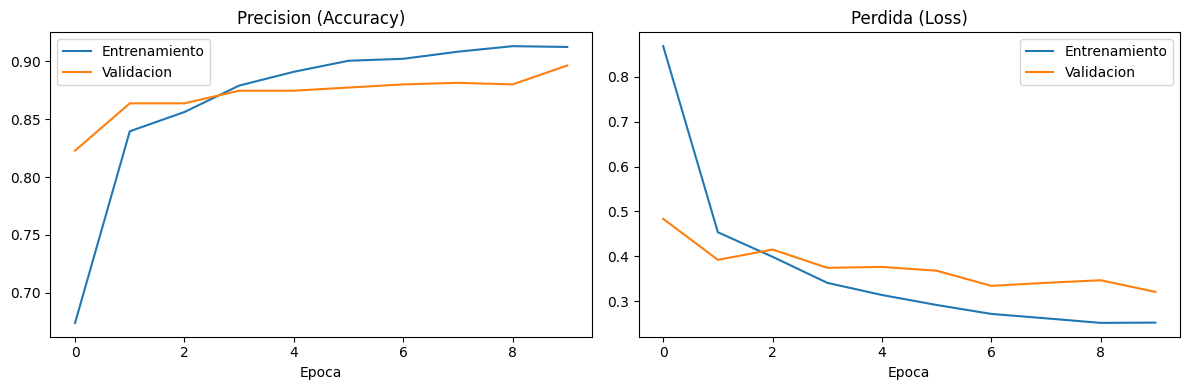

In [17]:
acc = history.history.get("accuracy", [])
val_acc = history.history.get("val_accuracy", [])
loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Entrenamiento")
plt.plot(val_acc, label="Validacion")
plt.title("Precision (Accuracy)")
plt.xlabel("Epoca")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Entrenamiento")
plt.plot(val_loss, label="Validacion")
plt.title("Perdida (Loss)")
plt.xlabel("Epoca")
plt.legend()
plt.tight_layout()
plt.show()

### Paso 9: Inferencia sobre Imagenes de Prueba

Tomamos un lote de imagenes de validacion, realizamos predicciones con el modelo adaptado y mostramos los resultados junto con el porcentaje de confianza:


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


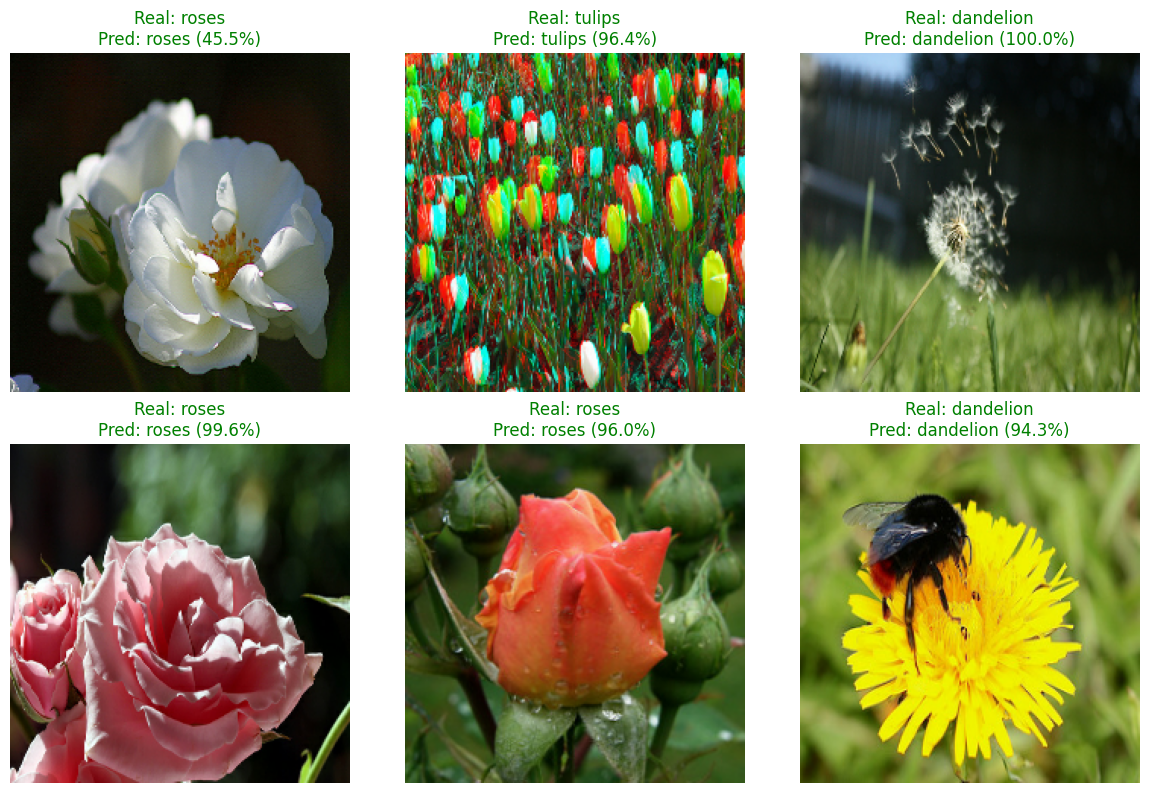

In [18]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    pred_classes = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12, 8))
    for i in range(min(6, len(images))):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        confidence = predictions[i][pred_classes[i]] * 100

        color = "green" if true_label == pred_label else "red"
        plt.title(f"Real: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Paso 10: Limpieza de Memoria y Recursos

Liberamos el modelo y los tensores de memoria para finalizar el laboratorio limpiamente:


In [19]:
import gc
del model, base_model
gc.collect()
print("Recursos liberados exitosamente.")

Recursos liberados exitosamente.
